In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("housing.csv")

In [8]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [10]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


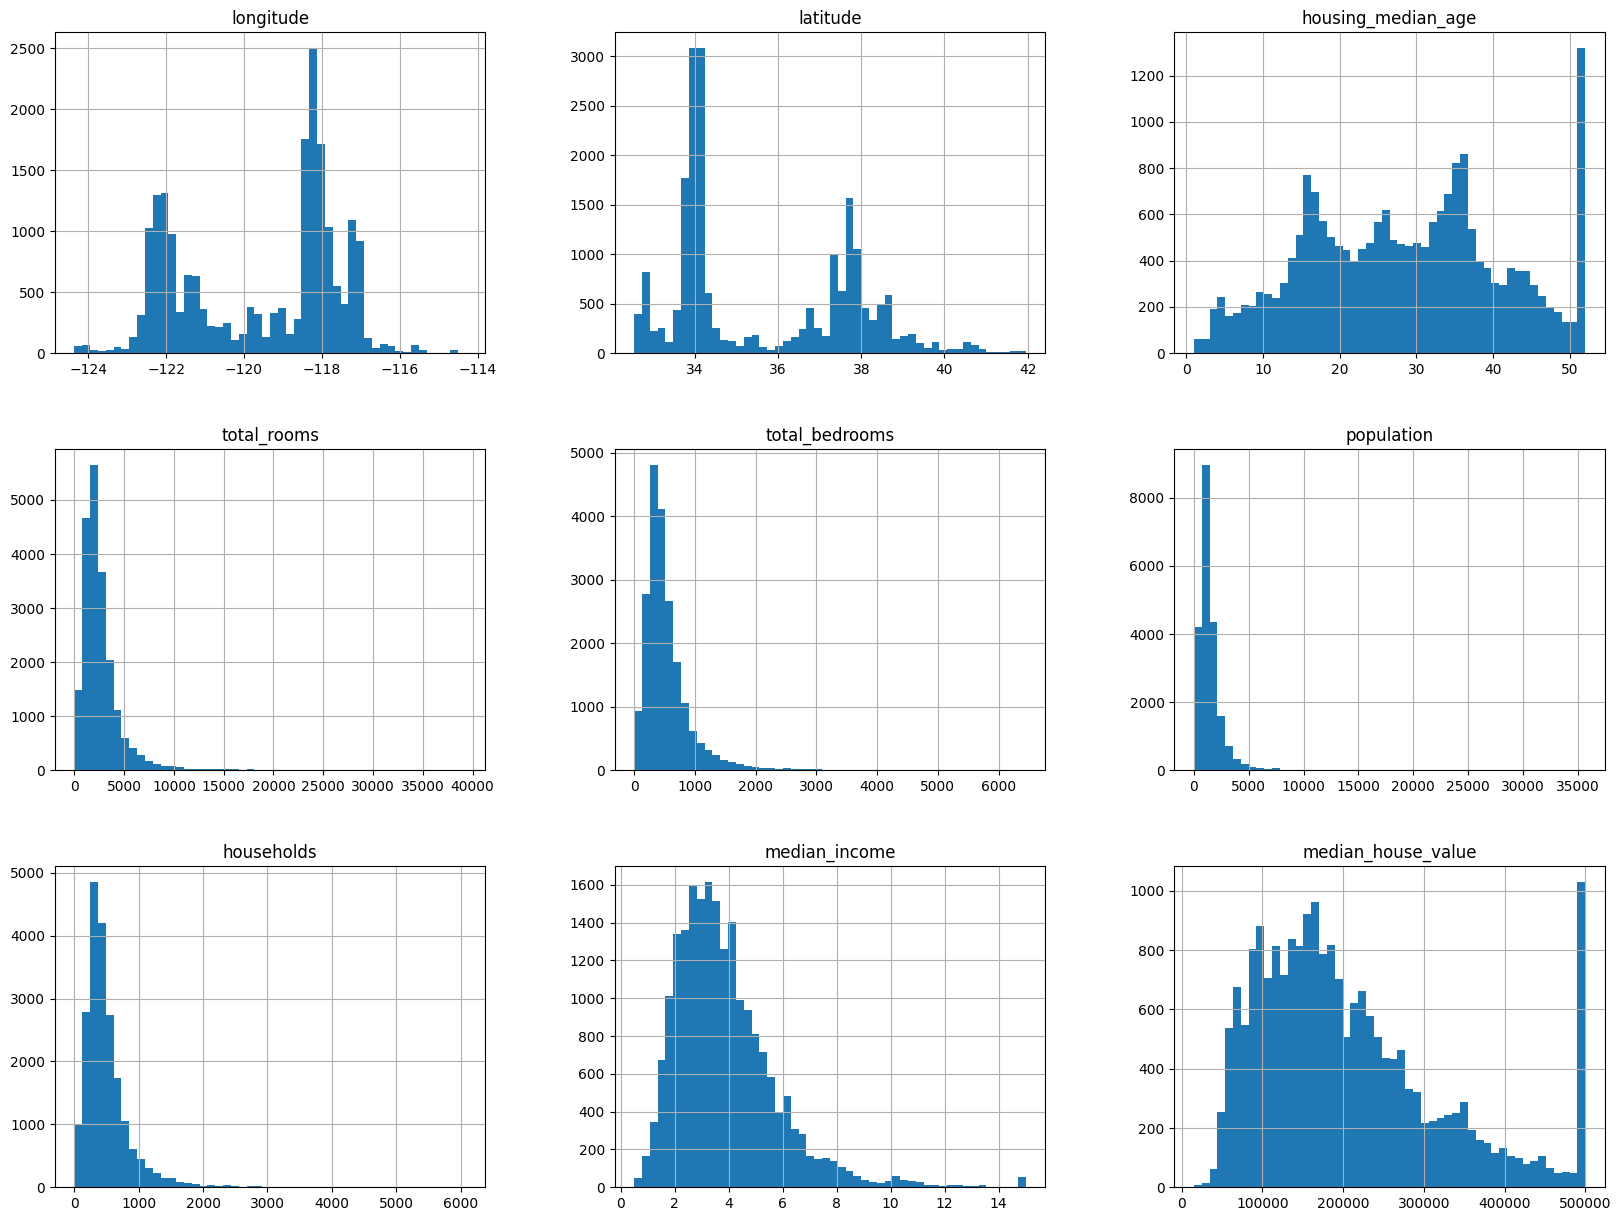

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20,15))
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=24092001)

In [14]:
# Creating income categorie for better stratified sampling
df['income_cat'] = pd.cut(df['median_income'],
                          bins=[0.,1.5,3.0,4.5,6.0, np.inf],
                          labels=[1,2,3,4,5])

<Axes: >

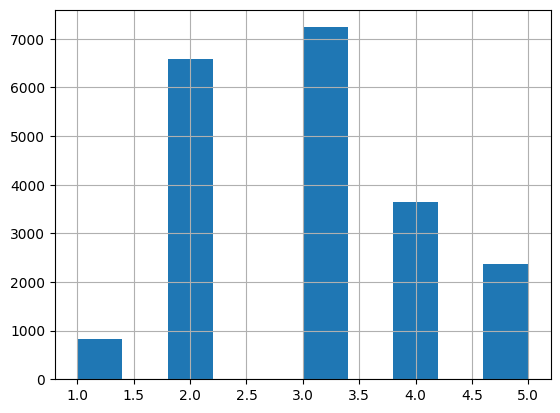

In [15]:
df['income_cat'].hist()

<Axes: >

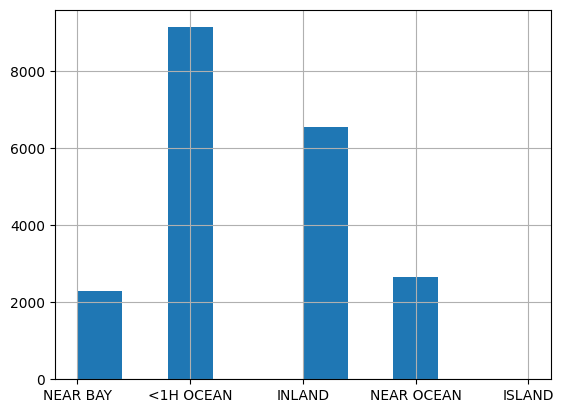

In [16]:
df['ocean_proximity'].hist()

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state= 24092001)

In [18]:
split

StratifiedShuffleSplit(n_splits=1, random_state=24092001, test_size=0.2,
            train_size=None)

In [23]:
for train_index, test_index in split.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [24]:
strat_test_set['income_cat'].value_counts()/len(strat_test_set)*100

income_cat
3    35.053295
2    31.879845
4    17.635659
5    11.434109
1     3.997093
Name: count, dtype: float64

In [26]:
strat_train_set['income_cat'].value_counts()/len(strat_train_test)*100

income_cat
3    35.059351
2    31.885901
4    17.629603
5    11.446221
1     3.978924
Name: count, dtype: float64

In [27]:
df['income_cat'].value_counts()/len(df)*100

income_cat
3    35.058140
2    31.884690
4    17.630814
5    11.443798
1     3.982558
Name: count, dtype: float64

In [28]:
# Now removing income_cat so that the data come back to normal
for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis = 1, inplace = True)

In [29]:
df = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

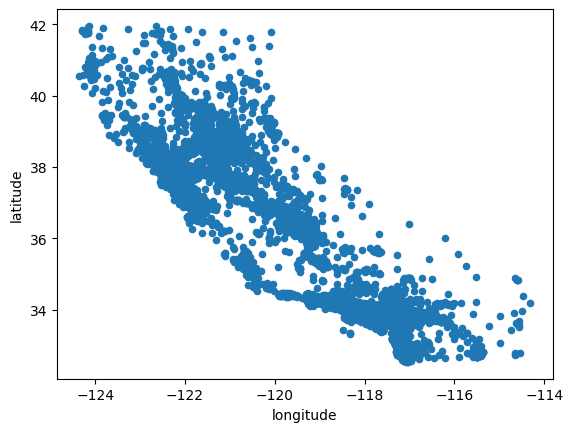

In [30]:
df.plot(kind = "scatter", x = 'longitude', y = 'latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

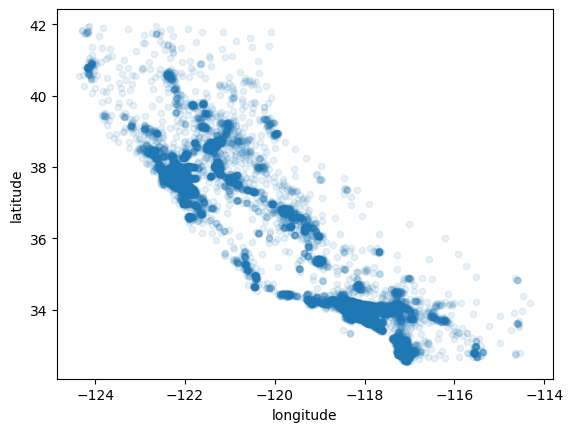

In [31]:
df.plot(kind ='scatter', x ='longitude', y='latitude', alpha = 0.1)

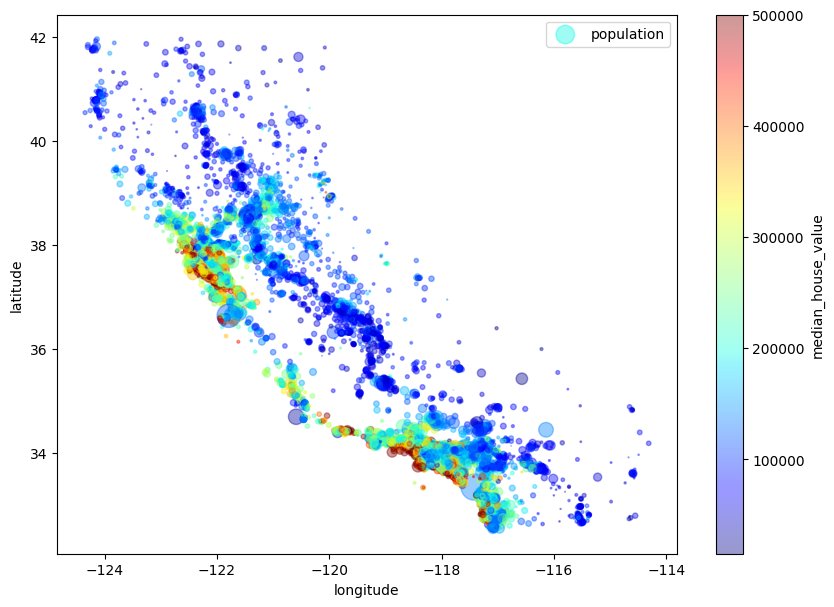

In [34]:
df.plot(kind = 'scatter', x ='longitude', y = 'latitude', alpha = 0.4,
        s = df['population']/100, label = 'population', figsize = (10,7), 
        c = 'median_house_value', cmap = plt.get_cmap('jet'), colorbar = True
        )
plt.legend()



In [46]:
# Correlation matrix 
corr_matrix = df.iloc[:, :-1].corr()

In [51]:
corr_matrix['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.684453
total_rooms           0.132818
housing_median_age    0.105088
households            0.064571
total_bedrooms        0.049500
population           -0.025690
longitude            -0.047420
latitude             -0.143218
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

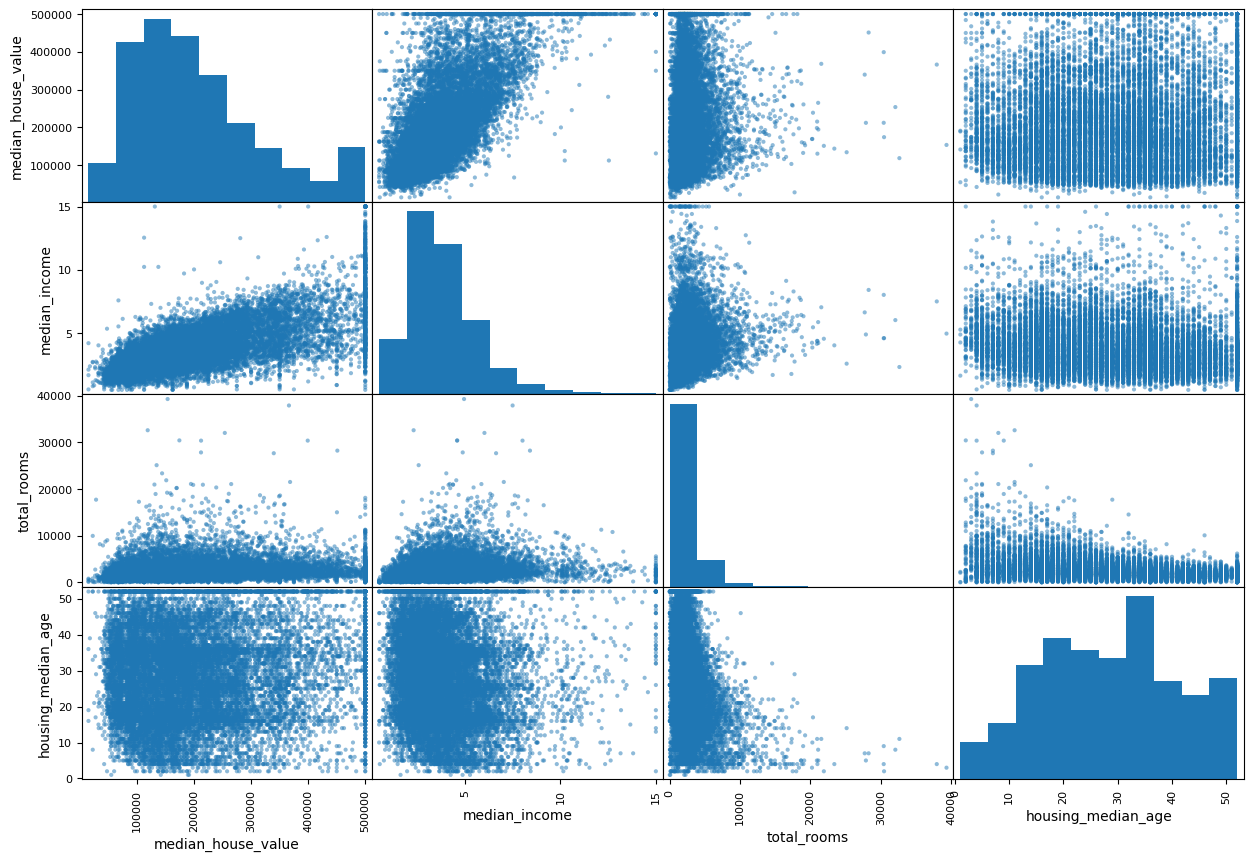

In [52]:
from pandas.plotting import scatter_matrix

attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']

scatter_matrix(df[attributes], figsize= (15,10))

<Axes: xlabel='median_income', ylabel='median_house_value'>

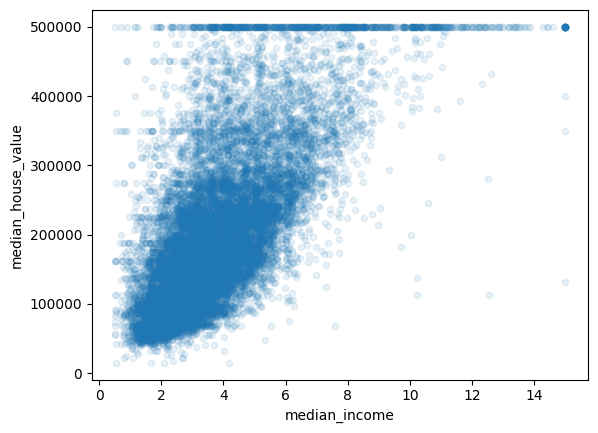

In [55]:
df.plot(kind = 'scatter', x = 'median_income', y = "median_house_value", alpha = 0.1)

In [56]:
df['rooms_per_household'] = df['total_rooms']/df['households']
df['bedrooms_per_room'] = df['total_bedrooms']/df['total_rooms']
df['population_per_household'] = df['population']/df['households']

In [59]:
corr_matrix = df.drop('ocean_proximity', axis = 1).corr()

In [61]:
corr_matrix['median_house_value'].sort_values(ascending= False)

median_house_value          1.000000
median_income               0.684453
rooms_per_household         0.157840
total_rooms                 0.132818
housing_median_age          0.105088
households                  0.064571
total_bedrooms              0.049500
population_per_household   -0.022283
population                 -0.025690
longitude                  -0.047420
latitude                   -0.143218
bedrooms_per_room          -0.255754
Name: median_house_value, dtype: float64

In [62]:
df = strat_train_set.drop("median_house_value", axis = 1)
df_label = strat_train_set['median_house_value'].copy()

In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 1436 to 19308
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16348 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.8 MB


### Data cleaning

In [ ]:
# option 1: remove corresponding instances 
df.dropna(subset=['total_bedrooms'])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1436,-122.01,37.98,29.0,2001.0,373.0,956.0,370.0,4.3170,NEAR BAY
1615,-122.11,37.87,33.0,3398.0,500.0,1351.0,457.0,6.5814,NEAR BAY
14723,-117.04,32.80,11.0,1802.0,440.0,630.0,428.0,2.0337,<1H OCEAN
10257,-117.86,33.87,12.0,1600.0,251.0,685.0,256.0,5.1784,<1H OCEAN
15470,-117.20,33.16,13.0,4503.0,1137.0,3094.0,1091.0,2.3159,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
11708,-120.20,39.12,15.0,2146.0,361.0,197.0,76.0,4.1316,INLAND
13137,-121.44,38.47,5.0,5666.0,1178.0,3139.0,1131.0,3.3608,INLAND
17423,-120.45,34.64,27.0,2696.0,622.0,1322.0,543.0,3.0352,NEAR OCEAN
3238,-119.56,36.10,25.0,1093.0,262.0,893.0,252.0,2.1300,INLAND


In [67]:
df.dropna(subset=['total_bedrooms']).isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [68]:
# option 2: delete the hold attribute
df.drop("total_bedrooms", axis = 1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
1436,-122.01,37.98,29.0,2001.0,956.0,370.0,4.3170,NEAR BAY
1615,-122.11,37.87,33.0,3398.0,1351.0,457.0,6.5814,NEAR BAY
14723,-117.04,32.80,11.0,1802.0,630.0,428.0,2.0337,<1H OCEAN
10257,-117.86,33.87,12.0,1600.0,685.0,256.0,5.1784,<1H OCEAN
15470,-117.20,33.16,13.0,4503.0,3094.0,1091.0,2.3159,<1H OCEAN
...,...,...,...,...,...,...,...,...
11708,-120.20,39.12,15.0,2146.0,197.0,76.0,4.1316,INLAND
13137,-121.44,38.47,5.0,5666.0,3139.0,1131.0,3.3608,INLAND
17423,-120.45,34.64,27.0,2696.0,1322.0,543.0,3.0352,NEAR OCEAN
3238,-119.56,36.10,25.0,1093.0,893.0,252.0,2.1300,INLAND


In [69]:
df.drop("total_bedrooms", axis = 1).isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [73]:
# option 3: fill with some values(mean, median, etc)
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace = True)

/tmp/ipykernel_16360/3489692234.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace = True)


1436      373.0
1615      500.0
14723     440.0
10257     251.0
15470    1137.0
          ...  
11708     361.0
13137    1178.0
17423     622.0
3238      262.0
19308     628.0
Name: total_bedrooms, Length: 16512, dtype: float64

In [74]:
# Using imputer 
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

In [75]:
df_num = df.drop("ocean_proximity", axis = 1)

In [76]:
imputer.fit(df_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [78]:
imputer.statistics_

array([-118.49  ,   34.25  ,   29.    , 2126.    ,  435.    , 1166.    ,
        410.    ,    3.5338])

In [79]:
X = imputer.transform(df_num)

In [80]:
df_tr = pd.DataFrame(X, columns= df_num.columns, index= df_num.index)

In [83]:
df_cat = df[['ocean_proximity']]

In [84]:
df_cat

,ocean_proximity
1436,NEAR BAY
1615,NEAR BAY
14723,<1H OCEAN
10257,<1H OCEAN
15470,<1H OCEAN
...,...
11708,INLAND
13137,INLAND
17423,NEAR OCEAN
3238,INLAND


In [85]:
df_cat.head(10)

,ocean_proximity
1436,NEAR BAY
1615,NEAR BAY
14723,<1H OCEAN
10257,<1H OCEAN
15470,<1H OCEAN
15930,NEAR BAY
13003,INLAND
8271,NEAR OCEAN
660,NEAR BAY
16624,NEAR OCEAN


In [86]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

In [87]:
df_cat_encoded = ordinal_encoder.fit_transform(df_cat)

In [90]:
df_cat_encoded[:10]

array([[3.],
       [3.],
       [0.],
       [0.],
       [0.],
       [3.],
       [1.],
       [4.],
       [3.],
       [4.]])

In [91]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [92]:
# Non ordinal categorical attribute
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()

In [93]:
df_cat_1hot = cat_encoder.fit_transform(df_cat)

In [94]:
df_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [95]:
df_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.]], shape=(16512, 5))

In [96]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [97]:
df.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 1436 to 19308
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16348 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.8 MB


In [98]:
# Custom transformers

from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3,4,5,6

class CombinedAttribute(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y = None):
        return self
    
    def transform(self, X):
        rooms_per_household = X [:,rooms_ix]/X[:, households_ix]
        population_per_household = X [:, population_ix]/X[:, households_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix]/X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]



In [99]:
attr_adder = CombinedAttribute(add_bedrooms_per_room=False)

In [100]:
attr_adder

,add_bedrooms_per_room,False


In [101]:
df_extra_attribs = attr_adder.transform(df.values)

In [104]:
df_extra_attribs.shape

(16512, 11)

In [105]:
# Data transformation pipelines

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttribute()),
    ("std_scaler", StandardScaler())
])

In [107]:
df_num_tr = num_pipeline.fit_transform(df_num)

In [108]:
df_num_tr

array([[-1.21788034,  1.09747451,  0.02791491, ..., -0.00672672,
        -0.04489761, -0.41698106],
       [-1.26775726,  1.04609895,  0.34601778, ...,  0.83351808,
        -0.01279834, -1.01029834],
       [ 1.26100249, -1.32184713, -1.40354798, ..., -0.50317443,
        -0.14071824,  0.45598209],
       ...,
       [-0.43980042, -0.4624742 , -0.13113652, ..., -0.19037202,
        -0.05775285,  0.25256027],
       [ 0.00410415,  0.21941955, -0.29018795, ..., -0.45052964,
         0.03782709,  0.38849335],
       [-1.65180953,  1.26561269, -0.68781653, ...,  0.16348869,
        -0.02582137, -0.44596521]], shape=(16512, 11))

In [110]:
list(df_num)

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [111]:
# Combining all transformations
from sklearn.compose import ColumnTransformer

num_attribs = list(df_num)

cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)
])

In [112]:
df_prepared = full_pipeline.fit_transform(df)

In [113]:
df_prepared

array([[-1.21788034,  1.09747451,  0.02791491, ...,  0.        ,
         1.        ,  0.        ],
       [-1.26775726,  1.04609895,  0.34601778, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.26100249, -1.32184713, -1.40354798, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.43980042, -0.4624742 , -0.13113652, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.00410415,  0.21941955, -0.29018795, ...,  0.        ,
         0.        ,  0.        ],
       [-1.65180953,  1.26561269, -0.68781653, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 16))

## Model training

In [115]:
from sklearn.linear_model import LinearRegression

In [116]:
lin_reg = LinearRegression()
lin_reg.fit(df_prepared, df_label)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [153]:
# Test on few instances of training set

some_instances = df.iloc[:3000]
some_labels = df_label.iloc[:3000]


In [154]:
some_instances_prepared = full_pipeline.fit_transform(some_instances)

In [155]:
some_instances_prepared.shape

(3000, 16)

In [156]:
lin_reg.predict(some_instances_prepared)

array([236974.93480865, 328372.83825629, 158432.76368625, ...,
       154452.96255084,  54022.40383396, 106166.75833834], shape=(3000,))

In [159]:
from sklearn.metrics import mean_squared_error

df_predictions = lin_reg.predict(df_prepared)
lin_mse = mean_squared_error(df_label, df_predictions)
lin_rmse = np.sqrt(lin_mse)

print("RMSE: ", lin_rmse)

RMSE:  68655.18136511697


In [160]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()

tree_reg.fit(df_prepared, df_label)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [161]:
df_predictions = tree_reg.predict(df_prepared)
tree_mse = mean_squared_error(df_label, df_predictions)
tree_rmse = np.sqrt(tree_mse)

tree_rmse

np.float64(0.0)